## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

### DEV: improving optimizer, deleting only occupied edges in chuck
1. **issue**: 
    - short traj chunk might not cover some s_top, which could result an immature deletion.
2. **sol**: 
    - set lower priority to delete unoccupied edges (not even evaluating them?)
    - delete a highly occupied edge (in chunk) when tie (softmax deletion? try hard deletion first)
    - or should we delete lowly occupied edge?
3. **rationale**:
    - when tie, highly occupied edges likely are less informative than lowly occupied one. because local scores are preserved on many revisits after deletion.
4. never occupied edges should be deleted first
5. **result**:
    - delete least occupied first yields better performance curve.

### FIX: unoccupied edges is still important to encode
1. **issue 1**: 
    - removing many unoccupied edges from full map degrades performance (see job `((1,3,2),20)` or `((1,4,2),20)`)
2. **sol 1**: 
    - `init_eid_removed` is deprecated since belief distribution can still diffuse into unoccupied tile
3. **issue 2**:
    - an edge can only be deleted if ever occupied, which causes a sparse map of only unoccupied edges when mapsize is small.
4. **sol 2**:
    - use q_map instead of occ_map to delete when tie?

### WHY: still go with erasing belief info when out of boundary
1. we aim to choose an optimization scheme that minimize the boundary effects
2. strong phantom inference when wall hugging (random walks don’t have)
    - at `PI=90` + pre-encoded wall edges, `mouse performance=58%` whereas `randwalk performance=3%`.
    - hard to argue if high compressibility from mouse traj is mainly from the  wall hugging.

### WHY NOT: optimize by gradually adding edges to a empty map
1. it is hard to take advantage of chunk schedule to speed up optimization
2. optimization would start from selecting 1 out of 930 edges to add.
3. is should be evaluted on full trajectory instead of chuck because the initial encoding impact performance greatly (unlike initial deletion from the full map)

## PACKAGE

In [94]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BASH PARAMETERS

In [95]:
job_id = 72#int(sys.argv[1])

In [96]:
in_dir = project_dir / "results"
out_dir = project_dir / "results" / "data_map"
#
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [97]:
# load tile trajectories
dat_traj_dict = pickle.load(open(in_dir / "dat_traj_dict", "rb"))

## SPECIFY ONE JOB BATCH
1. Select a subset of `dat_traj_dict` with a `pi_level` as a batch of jobs to run on cluster
2. the key for reading `dat_traj_dict` is `(type_id, id_1, id_2)` to output the value `(s_traj, a_traj, occ_map, s_top, xy_traj)`
3. for loading a mouse trajectory, use:
    - `type_id = 1`
    - `id_1` = 3 or 4 or ... (mouse_id)
    - `id_2` = 0 or 1 ... or 5 (rotation_id)
4. for loading a random trajectory, use:
    - `type_id = 0`
    - `id_1` = 0 or 1 or ... (seed)
    - `id_2` = -1 (-1 to specify n/a)
5. load a job as a nested tuple `((type_id, id_1, id_2), pi_level)`

In [98]:
# TEST PILOT BATCH: 1 pi_level, 6 traj for one mouse + 5 random trajectories
pi_level = 80
job_batch_test_pilot = {
    1: ((0,0,-1), pi_level), 
    2: ((0,1,-1), pi_level), 
    3: ((0,2,-1), pi_level), 
    4: ((0,3,-1), pi_level), 
    5: ((0,4,-1), pi_level),
    6: ((1,3,0), pi_level), 
    7: ((1,3,1), pi_level), 
    8: ((1,3,2), pi_level), 
    9: ((1,3,3), pi_level), 
    10: ((1,3,4), pi_level), 
    11: ((1,3,5), pi_level),
    12: ((1,4,0), pi_level),
    13: ((1,4,1), pi_level),
    14: ((1,4,2), pi_level),
    15: ((1,4,3), pi_level),
    16: ((1,4,4), pi_level),
    17: ((1,4,5), pi_level),
}

In [99]:
# FULL PILOT BATCH: 10 pi_level, 6 traj for one mouse x 2 + 5 random trajectories (170 jobs, 16K walltime)
seed_list = np.arange(5)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]
job_list_mouse_3 = [((1,3,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]
job_list_mouse_4 = [((1,4,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]

# pack
job_batch_pilot = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse_3 + job_list_mouse_4)}

In [100]:
job_batch = job_batch_pilot
len(job_batch)

170

In [109]:
job_batch_pilot[72]

((1, 3, 3), 30)

## LOCAL PARAMETERS

In [101]:
debug = False
n_parallel = 25

## PREP
### setting up belief distribution propagation

In [102]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)

# prep: map
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
eid_wall, sh_wall, n_edges_wall = get_eid_wall(sas_dict, ringsize, n_tiles, e_sh_arr)
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict, sh_wall)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

## LOAD JOB

In [103]:
# check if the saved file exists
dat_path = out_dir / f"dat_map_{job_batch[job_id]}"
dat_exists = os.path.exists(dat_path)

In [104]:
key, pi_level = job_batch[job_id]
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[key]
pi = pi_all[pi_level]

## RUN: map optimization

In [105]:
def run_map_optimizer(s_traj, a_traj, occ_map, s_top, pi, eid_removed, eid_remain, schedule):
    '''
    NOTE: deletion-based optimizer
    '''
    # mp
    def run_mp(param):
        # load
        map, chunk_id, chunksize = param
        
        # load chunk of trajectory
        s_traj_r, a_traj_r = get_one_traj_chunk(s_traj, a_traj, chunk_id, chunksize)
        
        # eval
        score, score_map, pq_traj = eval_one_map(map, s_traj_r, a_traj_r, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
        
        # # get p_map
        # p_map = pq_traj.sum(-1).mean(0)
        return score, score_map
    
    # eval full map
    score_max, _ = run_mp((eid_remain, None, None))
    score_iter = [score_max]
    
    # get initial candidate edges (from zeros of occ_map of full traj)
    s_unoccupied = np.where(occ_map == 0)[0]
    init_eid_cand = get_eid_from_s(s_unoccupied, e_sh_arr)
    if len(s_unoccupied) > 0:
        print(f"{len(init_eid_cand)} unoccupied edges found from full trajectory...")

    # iter
    for iter in np.arange(len(schedule)):
        # load schedule
        n_chunks, chunk_id, chunksize = schedule[iter]
        
        # find candidate edges to remove
        # if iter==0:
        #     _, _, p_map = run_mp((eid_remain, chunk_id, chunksize))
        for subiter in range(n_chunks):
            s_traj_r, _ = get_one_traj_chunk(s_traj, a_traj, chunk_id, chunksize)
            eid_cand = get_eid_cand_for_one_iter(eid_remain, init_eid_cand, s_traj_r, e_sh_arr, n_tiles)
            if len(eid_cand) > 0:
                eid_cand_exists = True
                break
            else:
                eid_cand_exists = False
                print(f"chunk {chunk_id} has no candidate edges to remove, trying next chunk...")
                chunk_id = (chunk_id + 1) % n_chunks # override until eid_cand is non-empty
                _, _ = run_mp((eid_remain, chunk_id, chunksize))
        if not eid_cand_exists:
            print(f"no candidate edges found in any chunk, using all remaining edges...")
            eid_cand = eid_remain # if no candidate edges found, use all remaining edges
        
        # eval candidates on one traj chunk
        eid_remain_cand = [eid_remain[eid_remain!=x] for x in eid_cand]
        param = [(x, chunk_id, chunksize) for x in eid_remain_cand]
        with multiprocess.Pool() as p:
            score_cand, _ = zip(*p.map(run_mp, param))
        
        # find top
        idx_top = np.argmax(score_cand)
        eid_top = eid_cand[idx_top] # top to be removed
        score_top = score_cand[idx_top]
        eid_remain = eid_remain_cand[idx_top]
        # p_map = p_map_cand[idx_top]

        # append
        eid_removed.append(eid_top)
        score_iter.append(score_top)
        
        # print
        print(f"iter {iter}: eval {len(eid_cand)} edges, remove edge {eid_top}, score = {score_top:.6f}, chunk_id = {chunk_id}/{n_chunks}")
    return score_iter, eid_removed

def eval_multiple_maps(map_list, s_traj, a_traj, s_top, pi):
    '''
    NOTE: 
    '''
    def run_mp(map):
        score, score_map, _ = eval_one_map(map, s_traj, a_traj, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
        return score, score_map
    
    # mp
    with multiprocess.Pool() as p:
        score_list, score_map_list = zip(*p.map(run_mp, map_list))
    score_list = np.array(score_list)
    return score_list, score_map_list

In [106]:
## RUN (100m)
if not dat_exists:
# if True:
    # get optimization schedule
    schedule = get_optimization_schedule(n_parallel, n_edges, s_traj)
    schedule = {x:schedule[x] for x in range(60)} # TEST RUN
    
    # initialization
    eid_removed, eid_remain = initialize_optimization(n_edges)

    # run optimization
    score_iter, eid_removed = run_map_optimizer(s_traj, a_traj, occ_map, s_top, pi, eid_removed, eid_remain, schedule)

    # eval all maps on full trajectory
    print('evaluating all maps on full trajectory...')
    map_iter = get_map_list_from_eid_removed(eid_removed, n_edges)
    score_iter_full, score_map_iter_full = eval_multiple_maps(map_iter, s_traj, a_traj, s_top, pi)

## PICKLE

In [35]:
if not dat_exists:
# if True:
    dat_map = score_iter_full, score_map_iter_full, eid_removed
    pickle.dump(dat_map, open(dat_path, "wb"))
    
else:
    score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(dat_path, "rb"))

## TEST

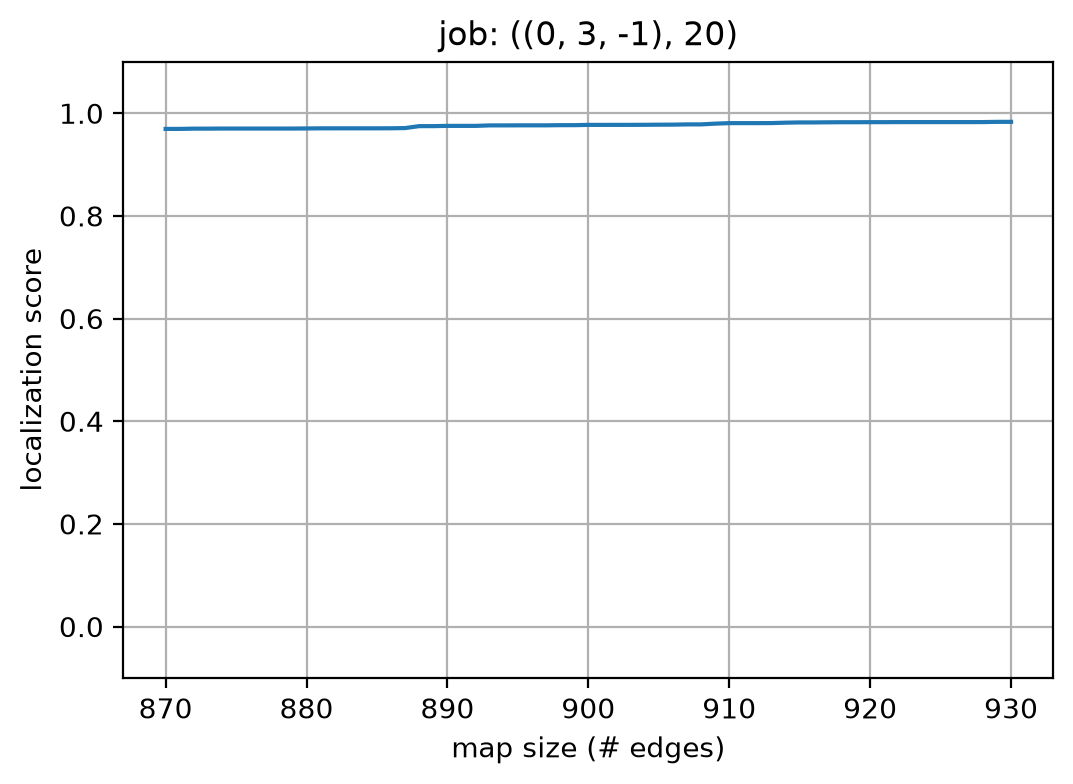

In [15]:
n_plot = 930

# plot
map_iter = get_map_list_from_eid_removed(eid_removed, n_edges)
mapsize_iter = [len(x) for x in map_iter]
plt.figure(figsize=(6,4), dpi=200)
plt.title(f"job: {job_batch[job_id]}")
plt.plot(mapsize_iter[::-1][:n_plot], score_iter_full[::-1][:n_plot])
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.ylim([-.1,1.1])
plt.grid()

if not os.path.exists(out_dir / 'plot'):
    os.makedirs(out_dir / 'plot')
plt.savefig(out_dir / 'plot' / f"map_score_{job_batch[job_id]}.png")

## RERUN

In [129]:
np.where(~np.array([os.path.exists(out_dir / f"dat_map_{y}") for x,y in job_batch.items()]))[0]+1

array([108])

In [127]:
os.path.exists(out_dir / f"dat_map_{job_batch[54]}")

False

In [126]:
job_batch

{1: ((0, 0, -1), 0),
 2: ((0, 1, -1), 0),
 3: ((0, 2, -1), 0),
 4: ((0, 3, -1), 0),
 5: ((0, 4, -1), 0),
 6: ((0, 0, -1), 10),
 7: ((0, 1, -1), 10),
 8: ((0, 2, -1), 10),
 9: ((0, 3, -1), 10),
 10: ((0, 4, -1), 10),
 11: ((0, 0, -1), 20),
 12: ((0, 1, -1), 20),
 13: ((0, 2, -1), 20),
 14: ((0, 3, -1), 20),
 15: ((0, 4, -1), 20),
 16: ((0, 0, -1), 30),
 17: ((0, 1, -1), 30),
 18: ((0, 2, -1), 30),
 19: ((0, 3, -1), 30),
 20: ((0, 4, -1), 30),
 21: ((0, 0, -1), 40),
 22: ((0, 1, -1), 40),
 23: ((0, 2, -1), 40),
 24: ((0, 3, -1), 40),
 25: ((0, 4, -1), 40),
 26: ((0, 0, -1), 50),
 27: ((0, 1, -1), 50),
 28: ((0, 2, -1), 50),
 29: ((0, 3, -1), 50),
 30: ((0, 4, -1), 50),
 31: ((0, 0, -1), 60),
 32: ((0, 1, -1), 60),
 33: ((0, 2, -1), 60),
 34: ((0, 3, -1), 60),
 35: ((0, 4, -1), 60),
 36: ((0, 0, -1), 70),
 37: ((0, 1, -1), 70),
 38: ((0, 2, -1), 70),
 39: ((0, 3, -1), 70),
 40: ((0, 4, -1), 70),
 41: ((0, 0, -1), 80),
 42: ((0, 1, -1), 80),
 43: ((0, 2, -1), 80),
 44: ((0, 3, -1), 80),
 4

# TEST batch

### test pilot (two mice)

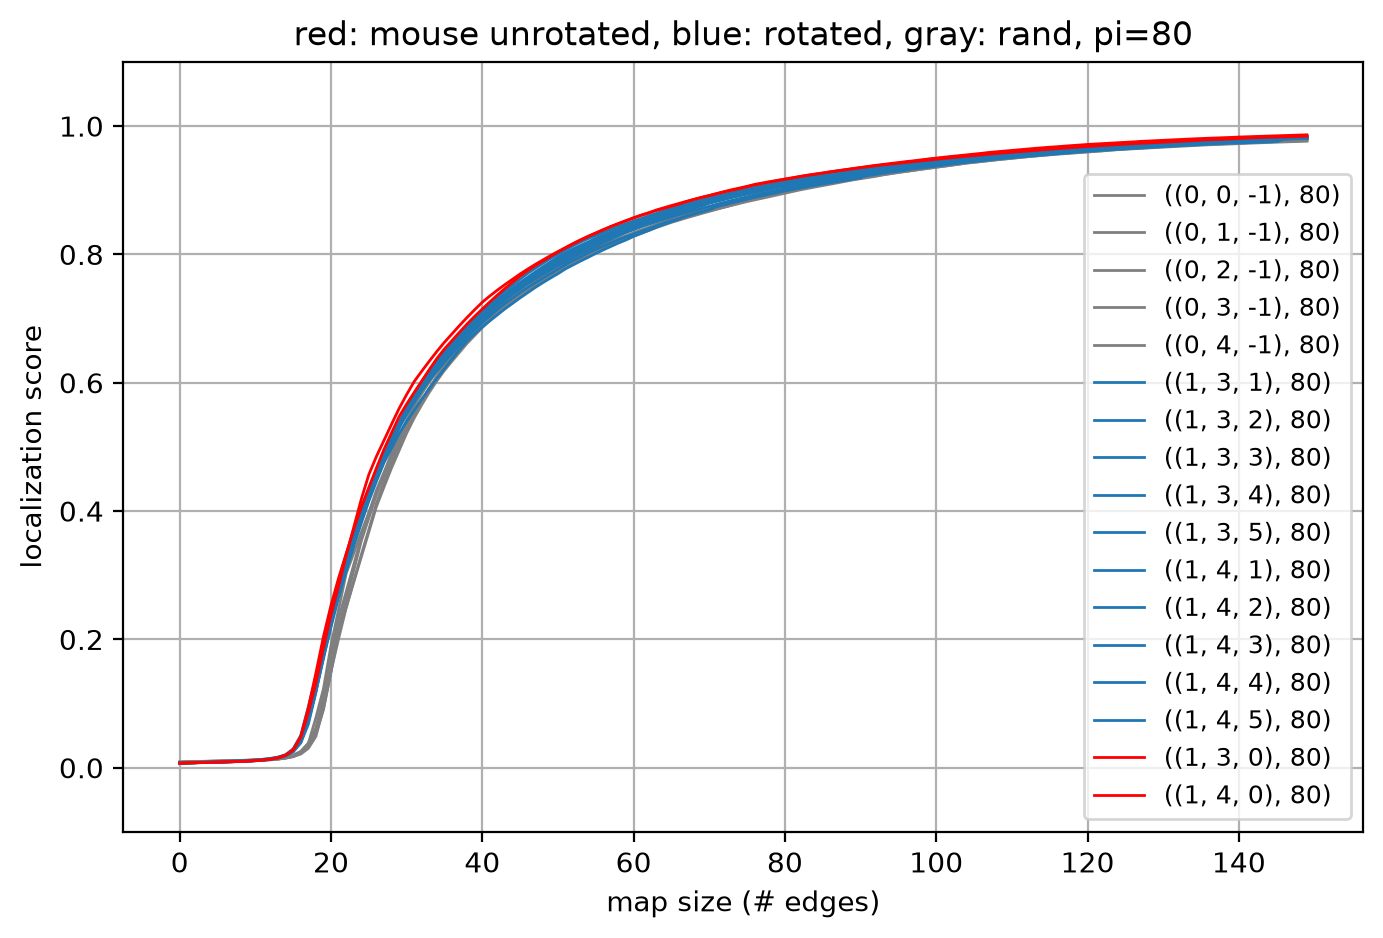

In [ ]:
job_selected = [1,2,3,4,5] + [7,8,9,10,11,13,14,15,16,17] + [6,12]
n_plot = 150

# plot
mapsize_iter = np.arange(n_edges, -1, -1)
colors = ['tab:gray']*5 + ['tab:blue']*10 + ['red']*2
plt.figure(figsize=(8,5), dpi=200)
plt.title(f'red: mouse unrotated, blue: rotated, gray: rand, pi={pi_level}')
for i, job_id in enumerate(job_selected):
    dat_path = out_dir / f"dat_map_{job_batch_pilot[job_id]}"
    score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(dat_path, "rb"))
    plt.plot(mapsize_iter[::-1][:n_plot], score_iter_full[::-1][:n_plot], label=f'{job_batch_pilot[job_id]}', lw=1, color=colors[i])
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.ylim([-.1,1.1])
plt.grid()
plt.legend(fontsize=9)

# if not os.path.exists(out_dir / 'plot'):
    # os.makedirs(out_dir / 'plot')
# plt.savefig(out_dir / 'plot' / f"map_score_{job_batch[job_id]}.png")

### full pilot (mouse 3)

In [ ]:
# job_id = 1
# score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(out_dir / f"dat_map_{job_batch[job_id]}", "rb"))

In [131]:
job_batch[108]

((1, 3, 3), 90)

### heatmap, random walk

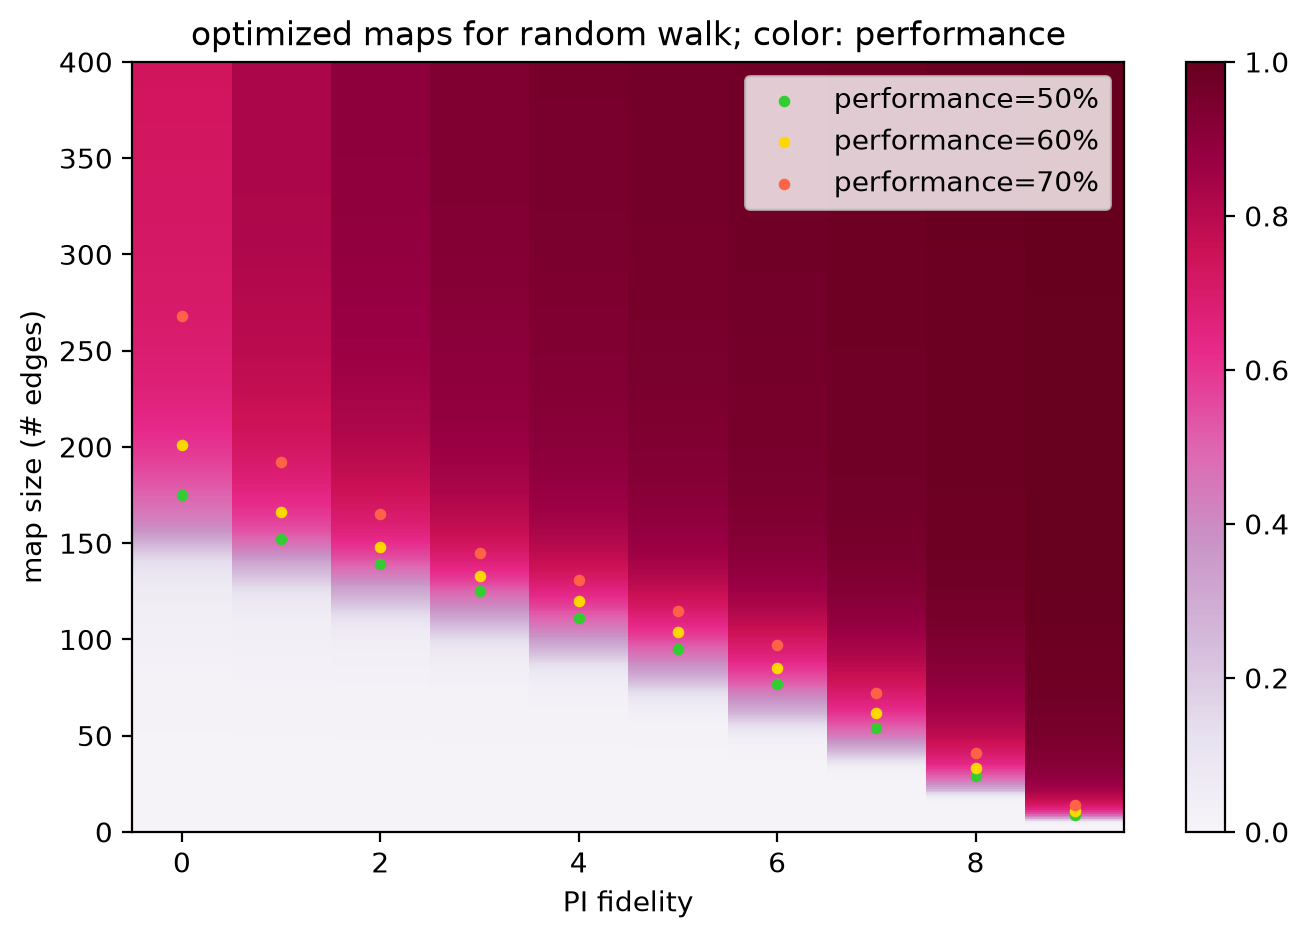

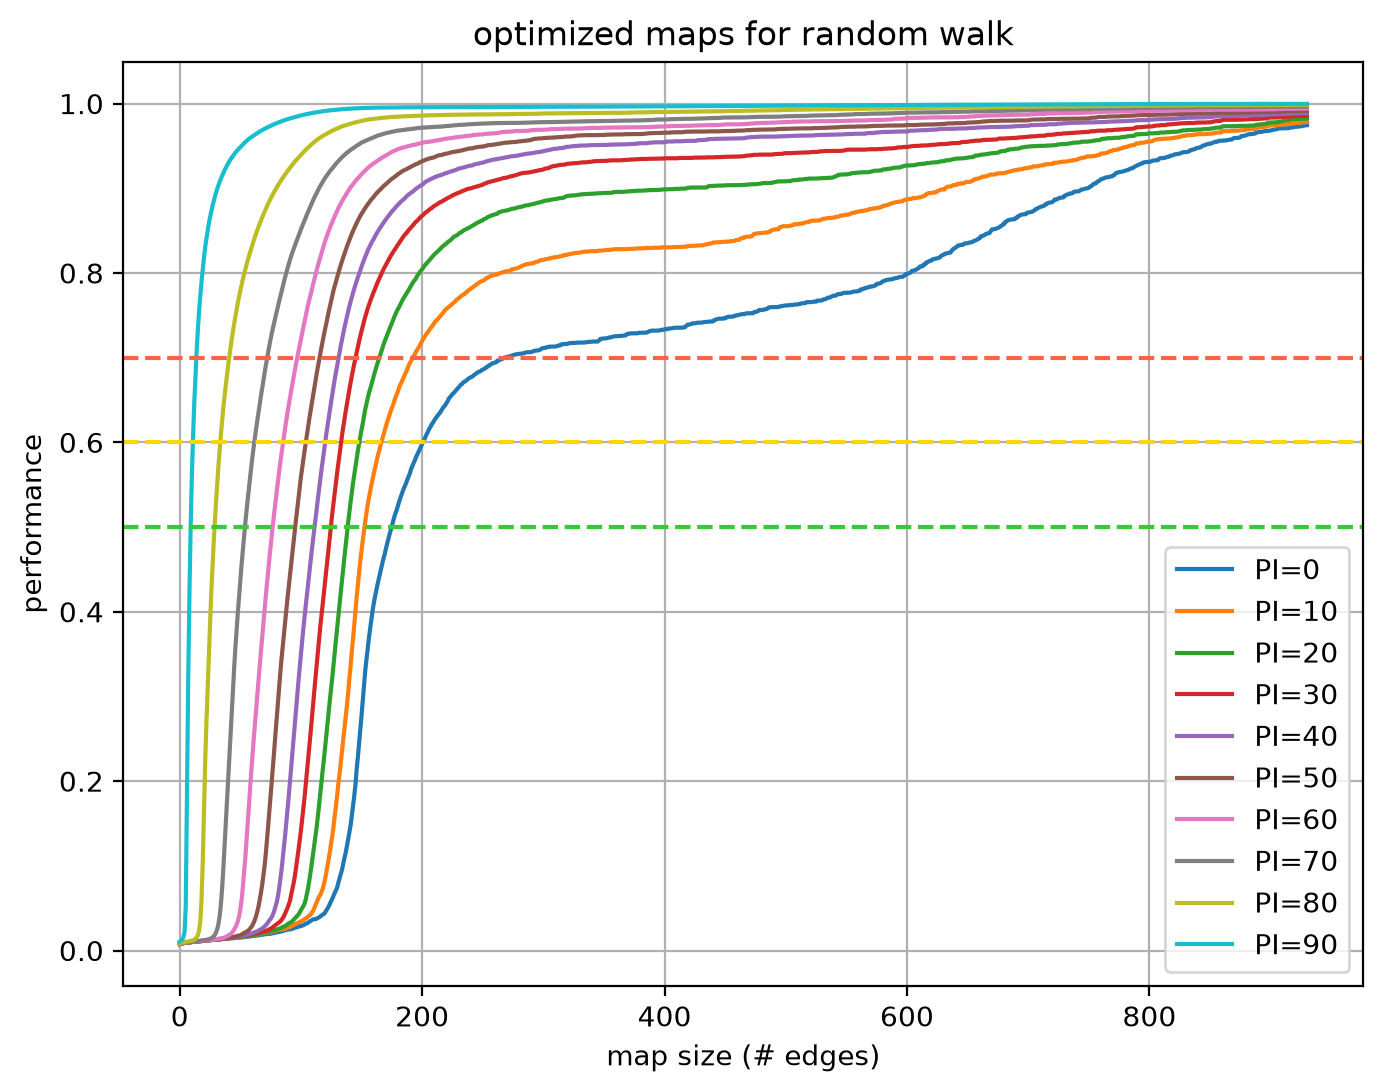

In [140]:
# prep
job_selected = np.arange(1, 51)
score_tensor = np.array([pickle.load(open(out_dir / f"dat_map_{job_batch_pilot[job_id]}", "rb"))[0] for job_id in job_selected]).reshape(10,5,-1)
score_arr = score_tensor.mean(1)[:,::-1]
mapsize_50 = [np.argmin(np.abs(x-.5)) for x in score_arr]
mapsize_60 = [np.argmin(np.abs(x-.6)) for x in score_arr]
mapsize_70 = [np.argmin(np.abs(x-.7)) for x in score_arr]

# plot
plt.figure(figsize=(8,5), dpi=200)
plt.title('optimized maps for random walk; color: performance')
plt.imshow(score_arr.T, aspect='auto', cmap='PuRd', origin='lower', vmin=0, vmax=1, interpolation='nearest')
plt.colorbar()
plt.scatter(np.arange(10), mapsize_50, color='limegreen', s=10, label='performance=50%')
plt.scatter(np.arange(10), mapsize_60, color='gold', s=10, label='performance=60%')
plt.scatter(np.arange(10), mapsize_70, color='tomato', s=10, label='performance=70%')
plt.ylim([0, 400])
plt.xlabel('PI fidelity')
plt.ylabel('map size (# edges)')
plt.legend()

# plot
plt.figure(figsize=(8,6), dpi=200)
plt.title('optimized maps for random walk')
for i,x in enumerate(score_arr[:,:]): plt.plot(x, label=f'PI={i*10}')
for y,c in zip([.5,.6,.7], ['limegreen', 'gold', 'tomato']): 
    plt.axhline(y, color=c, linestyle='--')
plt.xlabel('map size (# edges)')
plt.ylabel('performance')
plt.legend()
plt.grid()

### heatmap, mouse unrotated

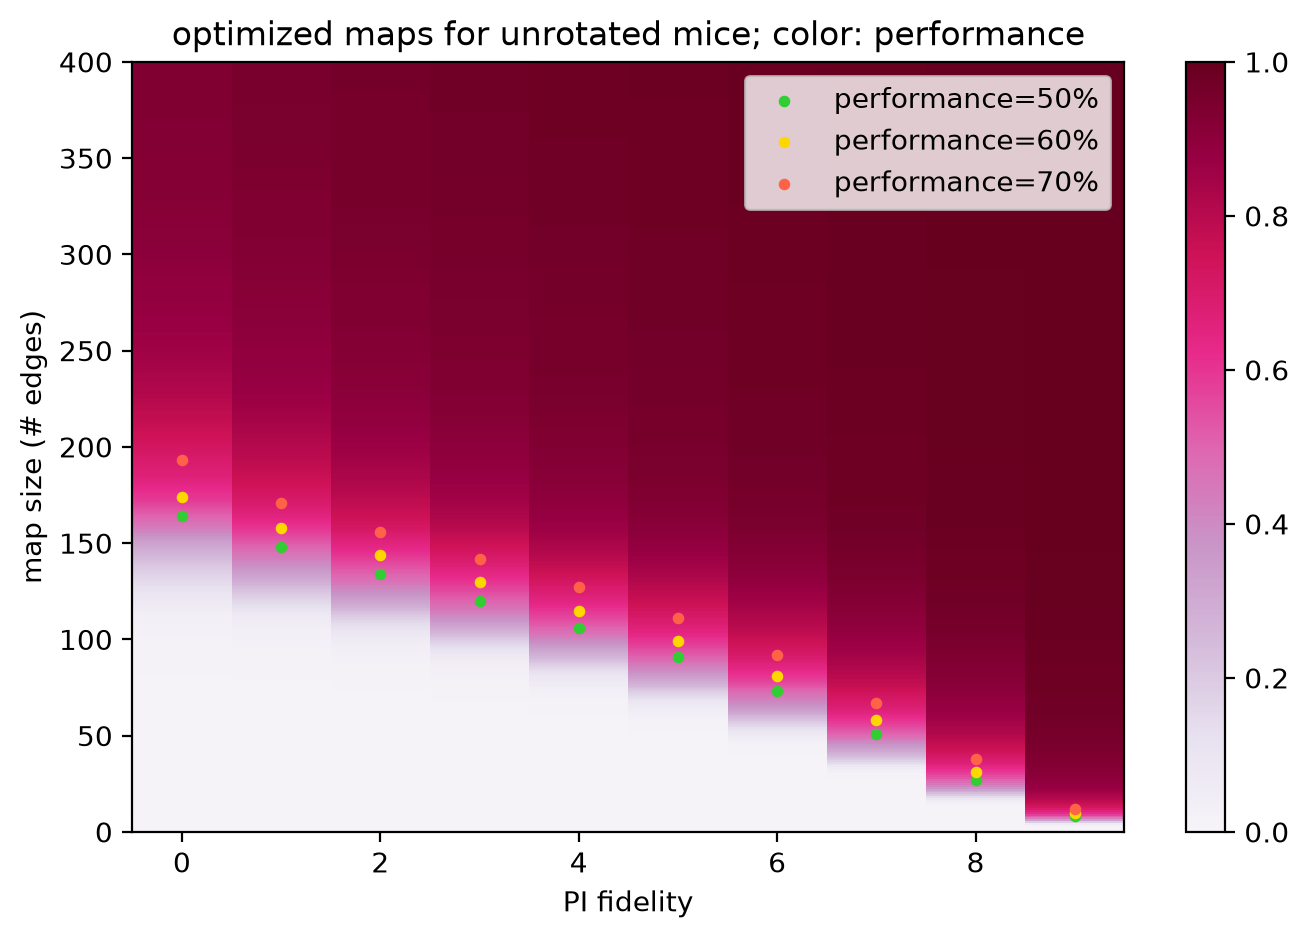

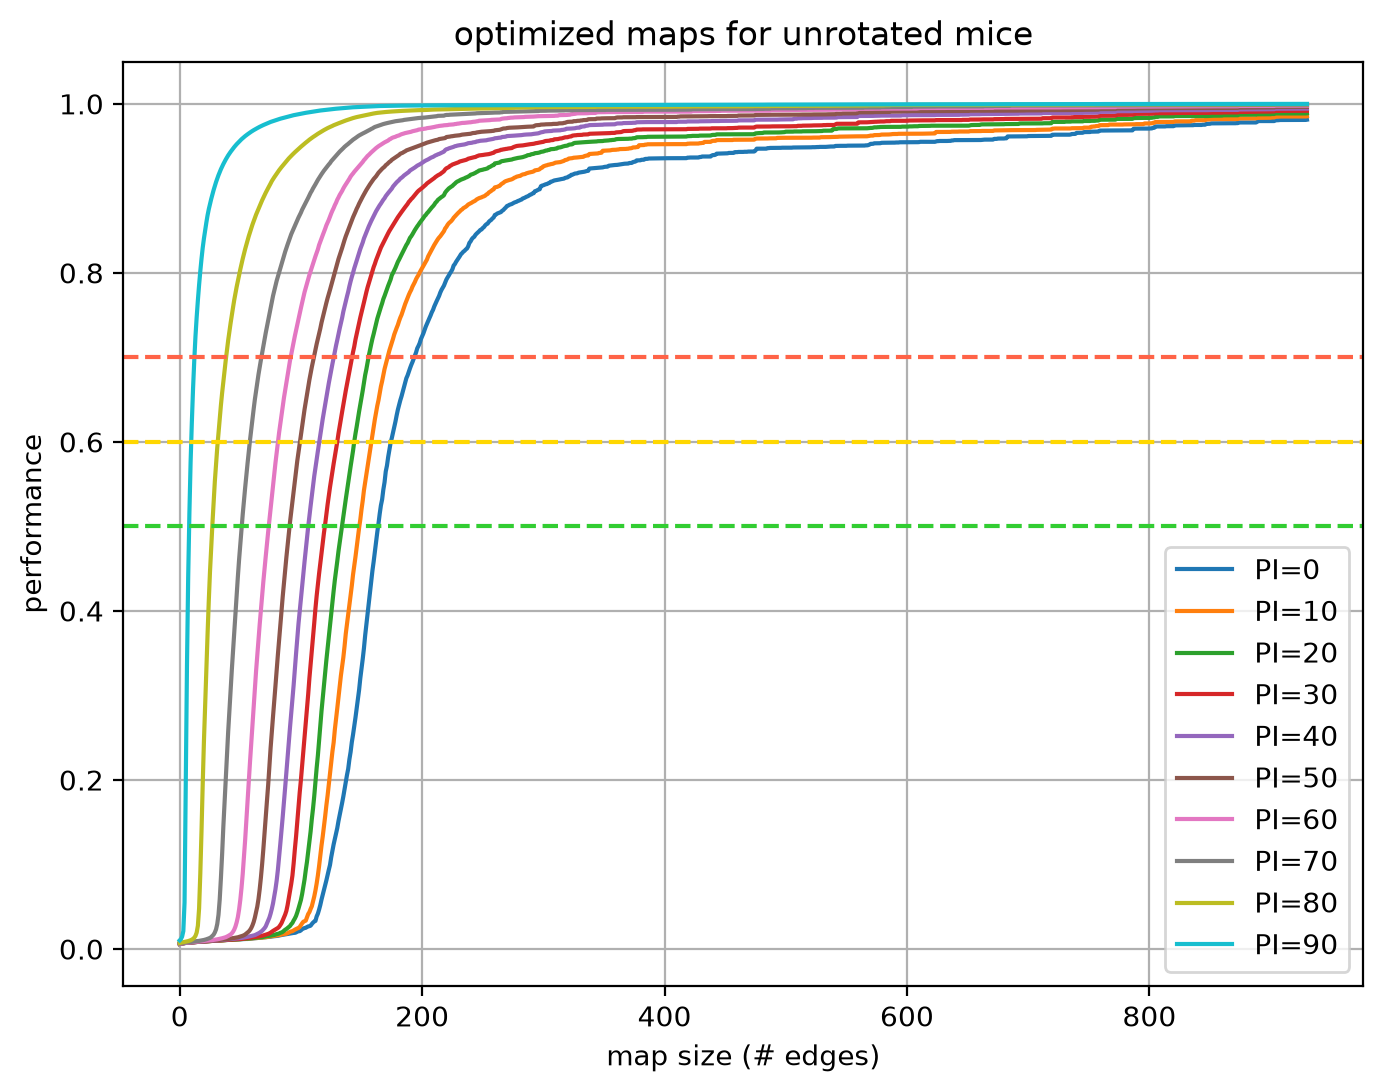

In [196]:
# prep
# job_selected = np.arange(1, 51)
job_selected = [x for x,((y,z,w),u) in job_batch.items() if w==0]
score_tensor = np.array([pickle.load(open(out_dir / f"dat_map_{job_batch_pilot[job_id]}", "rb"))[0] for job_id in job_selected]).reshape(2,10,-1)
score_arr = score_tensor.mean(0)[:,::-1]
mapsize_50 = [np.argmin(np.abs(x-.5)) for x in score_arr]
mapsize_60 = [np.argmin(np.abs(x-.6)) for x in score_arr]
mapsize_70 = [np.argmin(np.abs(x-.7)) for x in score_arr]

# plot
plt.figure(figsize=(8,5), dpi=200)
plt.title('optimized maps for unrotated mice; color: performance')
plt.imshow(score_arr.T, aspect='auto', cmap='PuRd', origin='lower', vmin=0, vmax=1, interpolation='nearest')
plt.colorbar()
plt.scatter(np.arange(10), mapsize_50, color='limegreen', s=10, label='performance=50%')
plt.scatter(np.arange(10), mapsize_60, color='gold', s=10, label='performance=60%')
plt.scatter(np.arange(10), mapsize_70, color='tomato', s=10, label='performance=70%')
plt.ylim([0, 400])
plt.xlabel('PI fidelity')
plt.ylabel('map size (# edges)')
plt.legend()

# plot
plt.figure(figsize=(8,6), dpi=200)
plt.title('optimized maps for unrotated mice')
for i,x in enumerate(score_arr[:,:]): plt.plot(x, label=f'PI={i*10}')
for y,c in zip([.5,.6,.7], ['limegreen', 'gold', 'tomato']): 
    plt.axhline(y, color=c, linestyle='--')
plt.xlabel('map size (# edges)')
plt.ylabel('performance')
plt.legend()
plt.grid()

### heatmap, mouse rotated

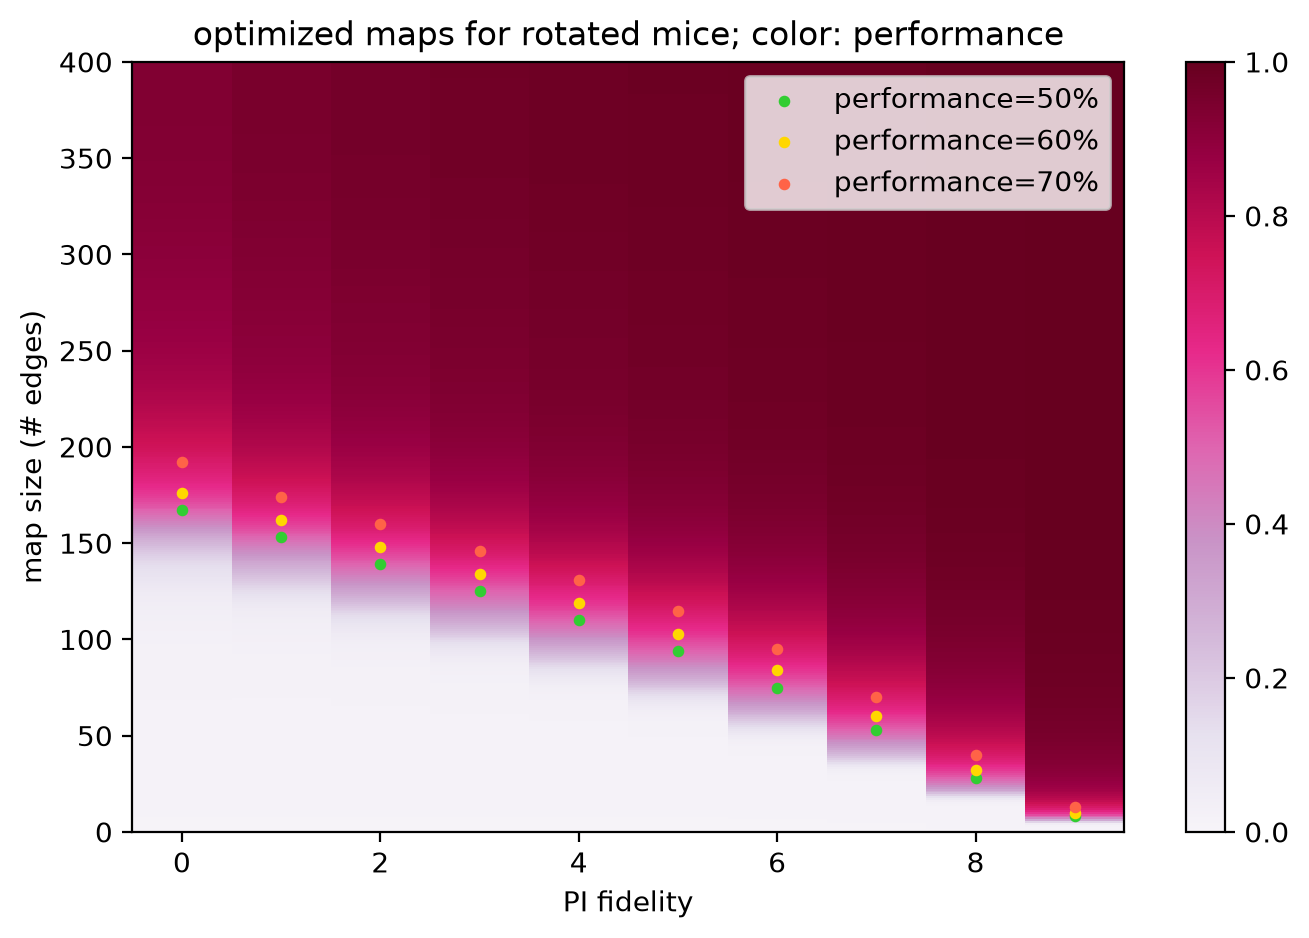

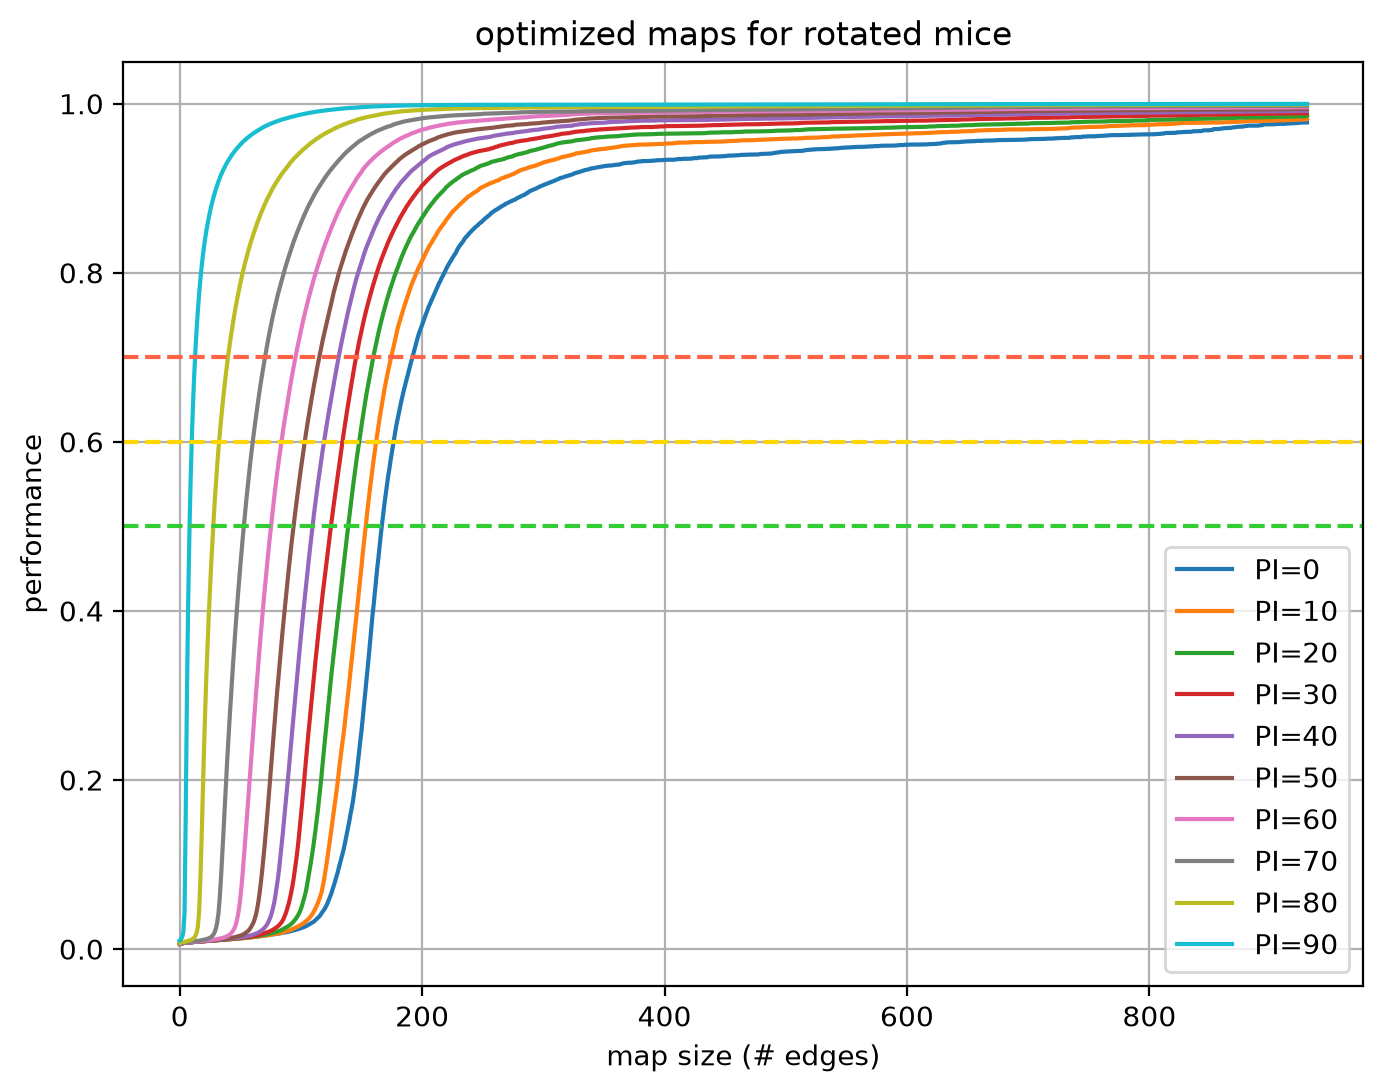

In [197]:
# prep
# job_selected = np.arange(1, 51)
job_selected = [x for x,((y,z,w),u) in job_batch.items() if w>0]
score_tensor = np.array([pickle.load(open(out_dir / f"dat_map_{job_batch_pilot[job_id]}", "rb"))[0] for job_id in job_selected]).reshape(2,10,5,-1)
score_arr = score_tensor.mean((0,2))[:,::-1]
mapsize_50 = [np.argmin(np.abs(x-.5)) for x in score_arr]
mapsize_60 = [np.argmin(np.abs(x-.6)) for x in score_arr]
mapsize_70 = [np.argmin(np.abs(x-.7)) for x in score_arr]

# plot
plt.figure(figsize=(8,5), dpi=200)
plt.title('optimized maps for rotated mice; color: performance')
plt.imshow(score_arr.T, aspect='auto', cmap='PuRd', origin='lower', vmin=0, vmax=1, interpolation='nearest')
plt.colorbar()
plt.scatter(np.arange(10), mapsize_50, color='limegreen', s=10, label='performance=50%')
plt.scatter(np.arange(10), mapsize_60, color='gold', s=10, label='performance=60%')
plt.scatter(np.arange(10), mapsize_70, color='tomato', s=10, label='performance=70%')
plt.ylim([0, 400])
plt.xlabel('PI fidelity')
plt.ylabel('map size (# edges)')
plt.legend()

# plot
plt.figure(figsize=(8,6), dpi=200)
plt.title('optimized maps for rotated mice')
for i,x in enumerate(score_arr[:,:]): plt.plot(x, label=f'PI={i*10}')
for y,c in zip([.5,.6,.7], ['limegreen', 'gold', 'tomato']): 
    plt.axhline(y, color=c, linestyle='--')
plt.xlabel('map size (# edges)')
plt.ylabel('performance')
plt.legend()
plt.grid()

### summary plot w/ confidence interval

In [209]:
score_tar = .7

In [ ]:
## mouse rotated
job_selected = [x for x,((y,z,w),u) in job_batch.items() if w>0]
score_tensor = np.array([pickle.load(open(out_dir / f"dat_map_{job_batch_pilot[job_id]}", "rb"))[0] for job_id in job_selected]).reshape(2,10,5,-1)
score_tensor = np.transpose(score_tensor, [0,2,1,3]).reshape(10,10,-1)[:,:,::-1]
#
mapsize_arr = np.argmin(np.abs(score_tensor-score_tar), axis=-1)
mapsize_mean = mapsize_arr.mean(0)
mapsize_ci = 1.96 * mapsize_arr.std(0)/mapsize_arr.shape[0]**.5

In [239]:
mapsize_mean

array([192.2, 174.2, 159.7, 145.6, 131.1, 115.1,  95.5,  70.5,  40. ,
        12.8])

In [238]:
mapsize_ci

array([4.75920935, 1.97561778, 1.38731453, 1.08066942, 1.08952026,
       1.08952026, 1.15123933, 0.79615576, 0.392     , 0.24792257])

In [240]:
## mouse unrotated
job_selected = [x for x,((y,z,w),u) in job_batch.items() if w==0]
score_tensor = np.array([pickle.load(open(out_dir / f"dat_map_{job_batch_pilot[job_id]}", "rb"))[0] for job_id in job_selected]).reshape(2,10,-1)[:,:,::-1]
#
mapsize_arr = np.argmin(np.abs(score_tensor-score_tar), axis=-1)
mapsize_mean = mapsize_arr.mean(0)
mapsize_ci = 1.96 * mapsize_arr.std(0)/mapsize_arr.shape[0]**.5

In [241]:
mapsize_mean

array([193.5, 171.5, 156. , 142. , 127. , 110.5,  91.5,  67. ,  38.5,
        12. ])

In [242]:
mapsize_ci

array([0.69296465, 0.69296465, 1.38592929, 1.38592929, 1.38592929,
       2.07889394, 0.69296465, 0.        , 0.69296465, 0.        ])